# Plant Disease Detection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling

In [5]:
# Define standard image size and batch size
img_height = 128
img_width = 128
batch_size = 32
data_dir = "./Potato" # Make sure your extracted dataset folder is named this

print("Loading Training Data:")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

print("\nLoading Validation Data:")
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

# Extract the class names (the names of your subfolders)
class_names = train_ds.class_names
print(f"\nClasses found: {class_names}")
num_classes = len(class_names)

Loading Training Data:
Found 2152 files belonging to 3 classes.
Using 1722 files for training.

Loading Validation Data:
Found 2152 files belonging to 3 classes.
Using 430 files for validation.

Classes found: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [6]:
model = Sequential()

# 1. Normalization Layer
model.add(Rescaling(1./255, input_shape=(img_height, img_width, 3)))

# 2. First Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3. Second Convolutional Block
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 4. Third Convolutional Block
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 5. Flatten and Dense Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=10
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 352ms/step - accuracy: 0.5947 - loss: 0.8198 - val_accuracy: 0.8395 - val_loss: 0.4630
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 282ms/step - accuracy: 0.8513 - loss: 0.4108 - val_accuracy: 0.8628 - val_loss: 0.3470
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 285ms/step - accuracy: 0.8885 - loss: 0.2927 - val_accuracy: 0.8860 - val_loss: 0.3256
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 323ms/step - accuracy: 0.9193 - loss: 0.2215 - val_accuracy: 0.9233 - val_loss: 0.1928
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 273ms/step - accuracy: 0.9448 - loss: 0.1603 - val_accuracy: 0.9209 - val_loss: 0.2082
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 300ms/step - accuracy: 0.9570 - loss: 0.1260 - val_accuracy: 0.9395 - val_loss: 0.1632
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 271ms/step - accuracy: 0.9710 - loss: 0.0846 - val_accuracy: 0.9419 - val_loss: 0.1313
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 274ms/step - accuracy: 0.9593 - loss: 0.0982 - val_accu

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


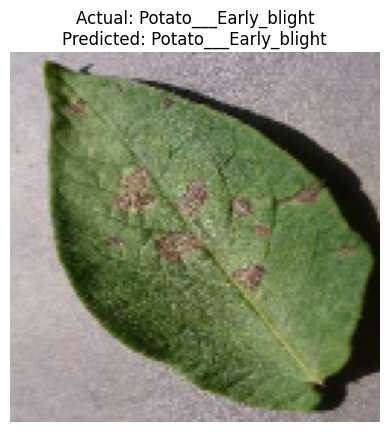

In [9]:
# Grab one batch of images and labels from the validation set
for images, labels in val_ds.take(1):
    test_image = images[0]
    actual_label = labels[0]
    
    # Model expects a batch, so we expand dimensions
    img_array = tf.expand_dims(test_image, 0) 
    
    # Make prediction
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    
    # Display the image
    plt.imshow(test_image.numpy().astype("uint8"))
    plt.title(f"Actual: {class_names[actual_label]}\nPredicted: {class_names[predicted_class]}")
    plt.axis("off")
    plt.show()